# OCR-based Image Classification

## Imports

In [ ]:
from TFM.Model_Notebooks.ocr_utils import *

# Install required Python packages if missing (Tesseract is system-level)
ensure_package('pytesseract')
ensure_package('Pillow', 'PIL')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('pandas')
ensure_package('tqdm')
ensure_package('numpy')
ensure_package('matplotlib')

print(sys.executable)
!{sys.executable} -m pip show opencv-python

OK: pytesseract available
OK: Pillow available
OK: scikit-learn available
OK: joblib available
OK: pandas available
OK: tqdm available
OK: numpy available
OK: matplotlib available


In [ ]:
ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
MODELS_DIR = ROOT / 'TFM' / 'Models'
MODELS_DIR.mkdir(exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.80
SEED = 42

# Create output folder if needed
OUTPUT_DIR = Path("ocr_cache")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

configure_tesseract()

pytesseract version: 5.5.0.20241111


## DATA Splitting

In [ ]:
# Load all data
class_names, all_samples = collect_samples(DATA_DIR, IMAGE_EXTENSIONS)

# Map labels to indices (needed for stratification)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

all_paths = [path for path, _ in all_samples]
all_labels = np.array([class_to_idx[label] for _, label in all_samples], dtype=np.int64)

# Stratified split
train_paths, val_paths, train_targets, val_targets = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels,
)

# Convert back to label names
idx_to_class = {v: k for k, v in class_to_idx.items()}

train_samples = [(path, idx_to_class[label]) for path, label in zip(train_paths, train_targets)]
val_samples = [(path, idx_to_class[label]) for path, label in zip(val_paths, val_targets)]

num_classes = len(class_names)

# Count occurrences
all_counts = Counter(all_labels.tolist())
train_counts = Counter(train_targets.tolist())
val_counts = Counter(val_targets.tolist())

all_image_counts = {class_names[idx]: all_counts.get(idx, 0) for idx in range(num_classes)}
train_image_counts = {class_names[idx]: train_counts.get(idx, 0) for idx in range(num_classes)}
val_image_counts = {class_names[idx]: val_counts.get(idx, 0) for idx in range(num_classes)}

print(f"Top-level class labels: {class_names}")
print(f"Number of classes: {num_classes}")

print("\nData image counts by class:")
for class_name in class_names:
    print(f"{class_name}: {all_image_counts[class_name]} images")

print("\nTraining image counts by class (80% split):")
for class_name in class_names:
    print(f"{class_name}: {train_image_counts[class_name]} images")

print("\nValidation image counts by class (20% split):")
for class_name in class_names:
    print(f"{class_name}: {val_image_counts[class_name]} images")

total_data_images = len(all_paths)
total_train_images = len(train_paths)
total_val_images = len(val_paths)

print(f"\nTotal images in Data: {total_data_images}")
print(f"Total training images: {total_train_images}")
print(f"Total validation images: {total_val_images}")

summary_df = pd.DataFrame({
    'Category': class_names,
    'Data Image Count': [all_image_counts[name] for name in class_names],
    'Train Image Count': [train_image_counts[name] for name in class_names],
    'Val Image Count': [val_image_counts[name] for name in class_names],
    'Train Percentage': [f"{100 * train_image_counts[name] / max(total_train_images, 1):.1f}%" for name in class_names],
    'Val Percentage': [f"{100 * val_image_counts[name] / max(total_val_images, 1):.1f}%" for name in class_names],
})

print("\nData Summary:")
print(summary_df)

Top-level class labels: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of classes: 8

Data image counts by class:
Banner aplicación: 153 images
Cierre aplicación: 312 images
Error aplicativo: 397 images
Error funcional: 517 images
Error terminal: 833 images
Indeterminado: 33 images
Revisión circuito: 2552 images
Timeout: 303 images

Training image counts by class (80% split):
Banner aplicación: 122 images
Cierre aplicación: 250 images
Error aplicativo: 318 images
Error funcional: 414 images
Error terminal: 666 images
Indeterminado: 26 images
Revisión circuito: 2042 images
Timeout: 242 images

Validation image counts by class (20% split):
Banner aplicación: 31 images
Cierre aplicación: 62 images
Error aplicativo: 79 images
Error funcional: 103 images
Error terminal: 167 images
Indeterminado: 7 images
Revisión circuito: 510 images
Timeout: 61 images

Total images in Data: 5100
Tot

## OCR and Extraction executing

In [ ]:
train_df = build_ocr_dataframe_from_samples(train_samples, class_names, 'train')
val_df = build_ocr_dataframe_from_samples(val_samples, class_names, 'val')
if 'Indeterminado' not in class_names:
    class_names.append('Indeterminado')

print('Class names:', class_names)

Save

In [ ]:
train_path = OUTPUT_DIR / "train_ocr.parquet"
val_path = OUTPUT_DIR / "val_ocr.parquet"

train_df.to_parquet(train_path, index=False)
val_df.to_parquet(val_path, index=False)

print(f"Saved to {train_path} and {val_path}")

NameError: name 'Path' is not defined

Load

In [ ]:
train_df = pd.read_parquet("ocr_cache/train_ocr.parquet")
val_df = pd.read_parquet("ocr_cache/val_ocr.parquet")

# Rebuild class names if needed
class_names = sorted(set(train_df['label']) | set(val_df['label']))
if 'Indeterminado' not in class_names:
    class_names.append('Indeterminado')

## Classifier

### Classificator SVC

In [ ]:
# sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
clf = SVC(probability=True)

def filter_empty_samples(df):
    return df[df['text'].str.strip() != ""].copy()

train_df_clean = filter_empty_samples(train_df)
val_df_clean = filter_empty_samples(val_df)

embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

def compute_embeddings(texts, model, batch_size=32):
    embeddings = model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True
    )
    return np.array(embeddings)

X_train = compute_embeddings(train_df_clean['text'], embedding_model)
X_val = compute_embeddings(val_df_clean['text'], embedding_model)

y_train = train_df_clean['label']
y_val = val_df_clean['label']

clf.fit(X_train, y_train)

NameError: name 'SVC' is not defined

### XGBoost

In [ ]:
"""
def filter_empty_samples(df):
    return df[df['text'].str.strip() != ""].copy()

# ✅ Filter first
train_df_clean = filter_empty_samples(train_df)
val_df_clean = filter_empty_samples(val_df)

# ✅ Extract labels AFTER filtering
y_train = train_df_clean['label']
y_val = val_df_clean['label']

# ✅ Encode AFTER filtering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# ✅ Embeddings
embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

def compute_embeddings(texts, model, batch_size=32):
    return np.array(
        model.encode(texts.tolist(), batch_size=batch_size, show_progress_bar=True)
    )
X_train = compute_embeddings(train_df_clean['text'], embedding_model)
X_val = compute_embeddings(val_df_clean['text'], embedding_model)

# ✅ Model
from xgboost import XGBClassifier

clf = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
)

# ✅ Train
clf.fit(X_train, y_train_encoded)

# ✅ Predict + decode
y_pred_encoded = clf.predict(X_val)
y_pred = le.inverse_transform(y_pred_encoded)
"""

Batches: 100%|██████████| 19/19 [00:07<00:00,  2.63it/s]


### Evaluate

In [ ]:
def evaluate_predictions(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Mask to exclude "Indeterminado" if needed for standard metrics?
    # (optional depending on how you want to treat it)
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # % of uncertain predictions
    uncertain_rate = np.mean(y_pred == "Indeterminado")

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "uncertain_rate": uncertain_rate
    }

OCR_THR = 0.90

def predict_with_threshold(probas, classes, threshold = OCR_THR):
    predictions = []

    for prob in probas:
        max_idx = np.argmax(prob)
        max_prob = prob[max_idx]
        predicted_class = classes[max_idx]

        if max_prob < threshold:
            predictions.append("Indeterminado")
        else:
            predictions.append(predicted_class)

    return predictions

def predict_with_rules(df, model, clf, threshold=OCR_THR):
    texts = df['text']
    
    # Compute embeddings for ALL samples
    embeddings = model.encode(texts.tolist(), show_progress_bar=True)

    probas = clf.predict_proba(embeddings)
    classes = clf.classes_

    predictions = []

    for i, text in enumerate(texts):
        text = text.strip()

        # ✅ Rule 1: Empty OCR
        if text == "":
            predictions.append("Empty")
            continue

        # ✅ Rule 2: Threshold for low confidence
        prob = probas[i]
        max_idx = np.argmax(prob)
        max_prob = prob[max_idx]
        pred_class = classes[max_idx]

        if max_prob < threshold:
            predictions.append("Indeterminado")
        else:
            predictions.append(pred_class)

    return predictions

def predict_with_rules_xgb(df, model, clf, le, threshold=OCR_THR):
    texts = df['text']
    
    embeddings = model.encode(texts.tolist(), show_progress_bar=True)

    probas = clf.predict_proba(embeddings)

    classes = le.inverse_transform(clf.classes_)

    predictions = []

    for i, text in enumerate(texts):
        text = text.strip()

        if text == "":
            predictions.append("Empty")
            continue

        prob = probas[i]
        max_idx = np.argmax(prob)
        max_prob = prob[max_idx]
        pred_class = classes[max_idx]

        if max_prob < threshold:
            predictions.append("Indeterminado")
        else:
            predictions.append(pred_class)

    return predictions

# For SVC
y_pred = predict_with_rules(val_df, embedding_model, clf, threshold=OCR_THR)
# For XGB
# y_pred = predict_with_rules_xgb(val_df, embedding_model, clf, le, threshold=OCR_THR)
extended_classes = sorted(list(set(class_names) | {"Empty"}))
print(classification_report(val_df['label'], y_pred, labels=extended_classes))

print(f"Evaluating on VAL with confidence threshold: {OCR_THR}")

scores = evaluate_predictions(val_df['label'], y_pred)
print("Scores:")
print(scores)

y_pred_no_empty = predict_with_rules(val_df_clean, embedding_model, clf, threshold=OCR_THR)

scores_no_empty = evaluate_predictions(val_df_clean['label'], y_pred_no_empty)

print("Scores (no empty):")
print(scores_no_empty)

Batches: 100%|██████████| 23/23 [00:04<00:00,  4.87it/s]


                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        19
Cierre aplicación       1.00      0.37      0.54        41
            Empty       0.00      0.00      0.00         0
 Error aplicativo       1.00      0.86      0.93        36
  Error funcional       1.00      1.00      1.00         2
   Error terminal       1.00      0.20      0.33       209
    Indeterminado       0.03      0.50      0.05         4
Revisión circuito       0.94      0.96      0.95       384
          Timeout       0.67      0.17      0.28        23

         accuracy                           0.67       718
        macro avg       0.74      0.56      0.56       718
     weighted avg       0.95      0.67      0.72       718

Evaluating on VAL with confidence threshold: 0.75
Scores:
{'accuracy': 0.6727019498607242, 'balanced_accuracy': 0.6325210105322917, 'macro_f1': 0.5637909450990345, 'weighted_f1': 0.720040628171462, 'uncertain_rate': np.float64(0.0

Batches: 100%|██████████| 19/19 [00:06<00:00,  2.95it/s]

Scores (no empty):
{'accuracy': 0.8370883882149047, 'balanced_accuracy': 0.8257109814142405, 'macro_f1': 0.746862535818184, 'weighted_f1': 0.8591287466963352, 'uncertain_rate': np.float64(0.12131715771230503)}


### Save predictions

In [ ]:
# ---- Predict ----
y_pred = predict_with_rules(val_df, embedding_model, clf, threshold=OCR_THR)

# ---- Build evaluation dataframe (VERY IMPORTANT) ----
texts = val_df['text'].tolist()
embeddings = embedding_model.encode(texts, show_progress_bar=True)

probas = clf.predict_proba(embeddings)
classes = clf.classes_

max_probs = probas.max(axis=1)
predicted_classes = [classes[np.argmax(p)] for p in probas]

eval_df = val_df.copy()
eval_df["prediction"] = y_pred
eval_df["predicted_class_raw"] = predicted_classes  # before threshold/rules
eval_df["max_probability"] = max_probs
eval_df["threshold"] = OCR_THR

# ---- Scores ----
scores = evaluate_predictions(val_df['label'], y_pred)

# ---- Save artifacts ----
# (NOTE: no vectorizer anymore — embeddings model is external)
dump(clf, MODELS_DIR / 'ocr_text_classifier_3.joblib')

# Optional: save class list for reproducibility
dump(classes, MODELS_DIR / 'ocr_classes_3.joblib')

# Save datasets
train_df.to_csv(MODELS_DIR / 'ocr_samples_train_3.csv', index=False)
val_df.to_csv(MODELS_DIR / 'ocr_samples_val_3.csv', index=False)

# Save evaluation outputs
eval_df.to_csv(
    MODELS_DIR / f'ocr_validation_predictions_threshold_{str(OCR_THR).replace(".", "p")}_v3.csv',
    index=False
)

# Save scores
with open(MODELS_DIR / 'ocr_validation_scores.json', 'w', encoding='utf-8') as f:
    json.dump(scores, f, indent=2, ensure_ascii=False)

print('Saved model artifacts to', MODELS_DIR.resolve())

Batches: 100%|██████████| 23/23 [00:08<00:00,  2.62it/s]


Saved model artifacts to C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Models


### Confusion matrix

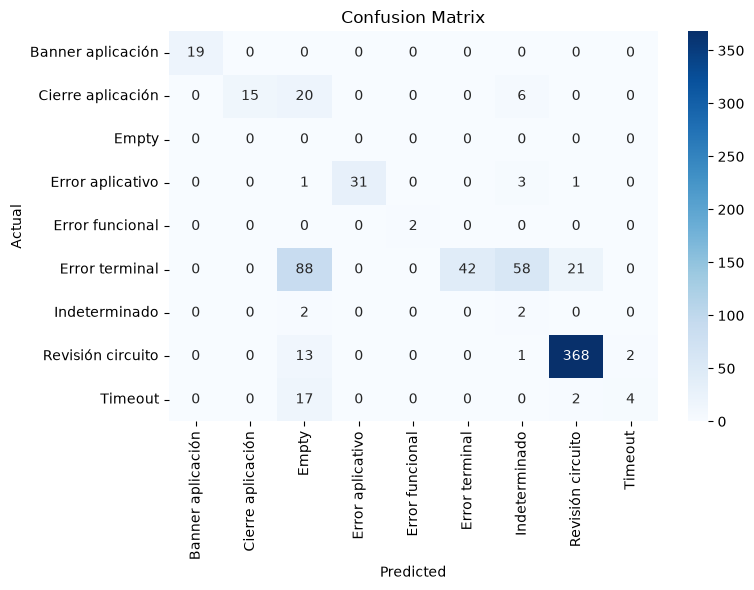

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Use same labels for everything
cm = confusion_matrix(val_df['label'], y_pred, labels=extended_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=extended_classes,
    yticklabels=extended_classes
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()

plt.show()

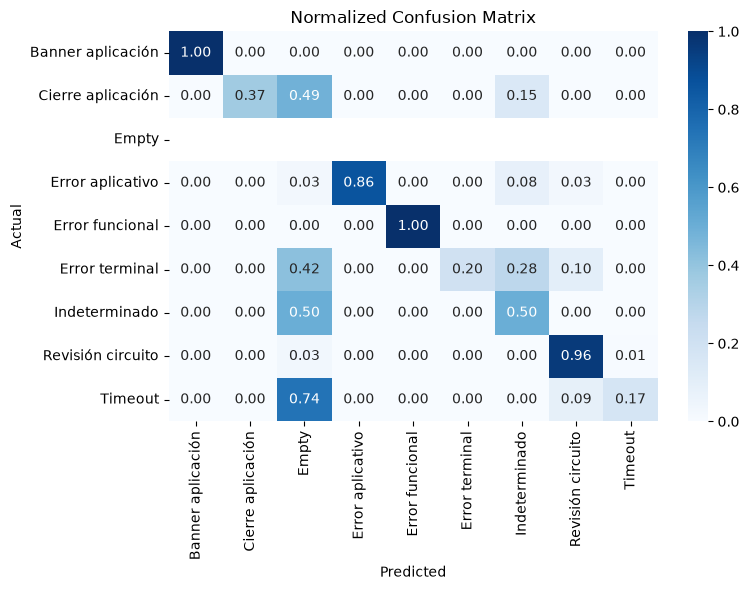

In [ ]:
import numpy as np

cm = confusion_matrix(val_df['label'], y_pred, labels=extended_classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=extended_classes,
    yticklabels=extended_classes
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()

plt.show()

### Logistic Regression

In [ ]:
# Train the OCR classifier on all Data images
if train_df['text'].fillna('').str.strip().eq('').all():
    raise RuntimeError('OCR returned empty text for every training image. Tesseract is required for this notebook.')

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['text'].fillna(''))
y_train = train_df['label']

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)
print('Training complete.')
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))

Training complete.
Train samples: 4405
Validation samples: 718


Evaluating on VAL with confidence threshold: 0.8
Scores:
{
  "accuracy": 0.3203342618384401,
  "balanced_accuracy": 0.2953864849255095,
  "macro_f1": 0.2311680844622684,
  "weighted_f1": 0.41905405118282807,
  "uncertain_rate": 0.6824512534818942
}

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       0.00      0.00      0.00        19
Cierre aplicación       1.00      0.17      0.29        41
 Error aplicativo       1.00      0.64      0.78        36
  Error funcional       0.00      0.00      0.00         2
   Error terminal       1.00      0.00      0.01       209
    Indeterminado       0.01      1.00      0.02         4
Revisión circuito       0.99      0.51      0.67       384
          Timeout       1.00      0.04      0.08        23

         accuracy                           0.32       718
        macro avg       0.62      0.30      0.23       718
     weighted avg       0.96      0.32      0.42       718



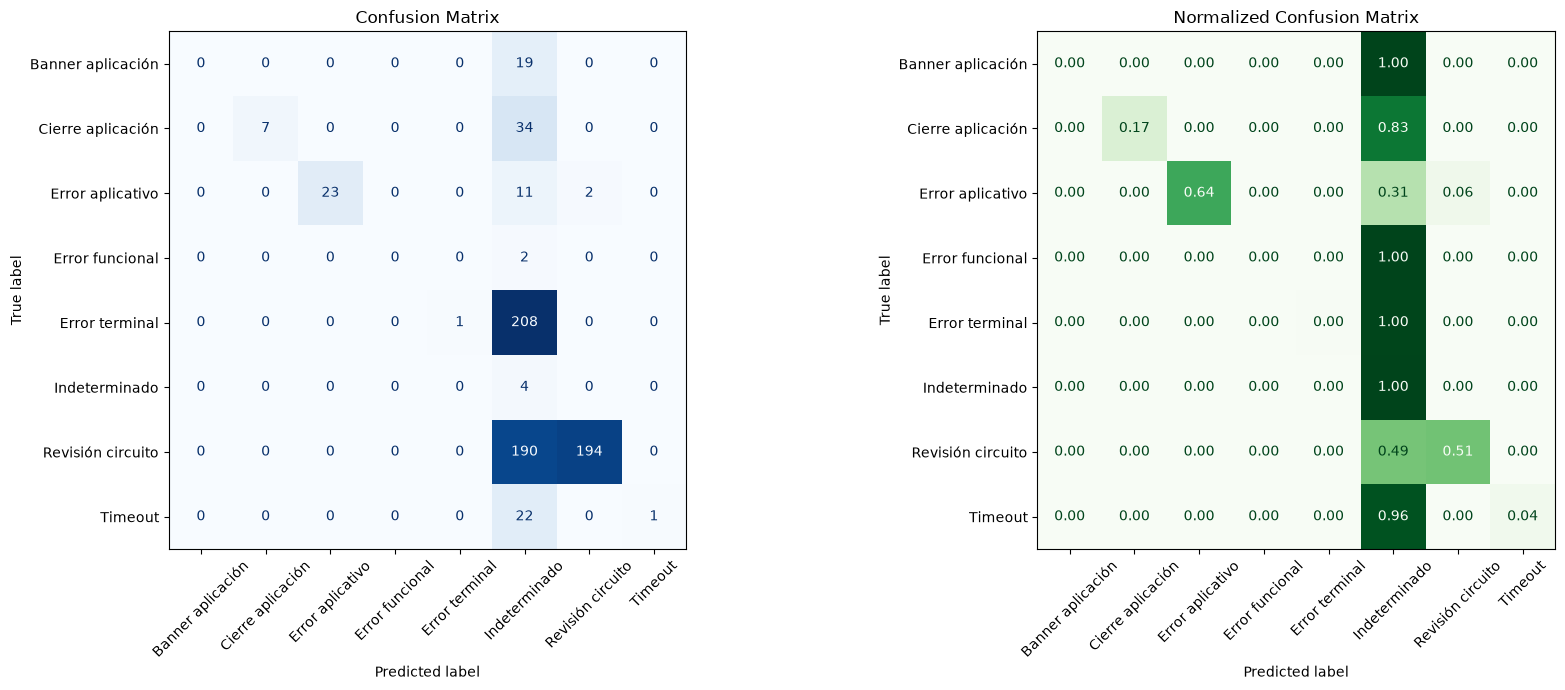

Validation rows: 718


In [ ]:
# Evaluate on VAL with the {CONFIDENCE_THRESHOLD} confidence rule
print('Evaluating on VAL with confidence threshold:', CONFIDENCE_THRESHOLD)
X_val = vectorizer.transform(val_df['text'].fillna(''))
val_probabilities = clf.predict_proba(X_val)
raw_indices = val_probabilities.argmax(axis=1)
raw_labels = clf.classes_[raw_indices]
confidence = val_probabilities.max(axis=1)
final_labels = np.where(confidence >= CONFIDENCE_THRESHOLD, raw_labels, 'Indeterminado')

eval_df = val_df.copy().reset_index(drop=True)
eval_df['raw_prediction'] = raw_labels
eval_df['confidence'] = confidence
eval_df['prediction'] = final_labels
eval_df['is_indeterminate'] = eval_df['prediction'].eq('Indeterminado')

scores = {
    'accuracy': float(accuracy_score(eval_df['label'], eval_df['prediction'])),
    'balanced_accuracy': float(balanced_accuracy_score(eval_df['label'], eval_df['prediction'])),
    'macro_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='weighted', zero_division=0)),
    'uncertain_rate': float(eval_df['is_indeterminate'].mean()),
}

print('Scores:')
print(json.dumps(scores, indent=2))
print('\nClassification report:')
print(classification_report(eval_df['label'], eval_df['prediction'], labels=class_names, zero_division=0))

cm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names)
cm_norm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title('Confusion Matrix')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ocr_confusion_matrix_2.png', dpi=200, bbox_inches='tight')
plt.show()

print('Validation rows:', len(eval_df))

In [ ]:
# Inference helper with the same confidence rule
def predict_image_class_from_ocr(image_path, confidence_threshold=CONFIDENCE_THRESHOLD, vectorizer_path=MODELS_DIR / 'ocr_vectorizer_2.joblib', clf_path=MODELS_DIR / 'ocr_text_classifier_2.joblib'):
    vec = load(vectorizer_path)
    model = load(clf_path)
    text = extract_text_from_image(image_path)
    if not text:
        return {'predicted': 'Indeterminado', 'raw_prediction': 'Indeterminado', 'confidence': 0.0, 'text': ''}
    features = vec.transform([text])
    probabilities = model.predict_proba(features)[0]
    index = int(probabilities.argmax())
    raw_label = model.classes_[index]
    confidence = float(probabilities[index])
    predicted = raw_label if confidence >= confidence_threshold else 'Indeterminado'
    return {'predicted': predicted, 'raw_prediction': raw_label, 'confidence': confidence, 'text': text}

example_path = val_df.iloc[0]['path'] if len(val_df) else train_df.iloc[0]['path']
print('Example path:', example_path)
print(predict_image_class_from_ocr(example_path))

Example path: C:\Users\ibf\Desktop\TFM\Nou_projecte\VAL\Banner aplicación\20260528131637_100097.png
{'predicted': 'Indeterminado', 'raw_prediction': 'Banner aplicación', 'confidence': 0.5594849151336734, 'text': '¿Nos permites acceder a tu geolocalización?\n\nEl permiso de ubicación solo lo utilizamos si autorizas\na la aplicación, y nos permite acceder a los datos de\ngeolocalización para:\n\nUn tratamiento comercial (si además tenemos tu\nconsentimiento)\n\n¡y Finalidades de lucha contra el fraude\n\nOfrecerte determinados servicios de la aplicación, como\nmostrarte la ubicación de la oficina más cercana\n\nLos datos de geolocalización se recogen únicamente si la\ngeolocalización está activada en el dispositivo, y se puede\nconfigurar en todo momento desde tu teléfono accediendo a\nAjustes>Geolocalización.\n\nCon carácter general, utilizaremos los datos de geolocalización\nen primer plano; por esta razón, te informaremos previamente\n\nen aquellos casos en que puedan utilizarse en se